

*   **Student: L Saohatse (EDUV14018857)**
*   **Stream: BSc Hons Data Science**




# Question 1

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv('sales.csv', index_col=0)
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date
0,1,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,08/11/2017
1,2,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,08/11/2017
2,3,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12/06/2017
3,4,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11/10/2016
4,5,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11/10/2016


## 1.1. Clean and prepare the dataset for analysis by performing all necessary data cleaning and transformation steps.

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Ship Date      9800 non-null   object 
 3   Ship Mode      9800 non-null   object 
 4   Customer ID    9800 non-null   object 
 5   Customer Name  9800 non-null   object 
 6   Segment        9800 non-null   object 
 7   Country        9800 non-null   object 
 8   City           9800 non-null   object 
 9   State          9800 non-null   object 
 10  Postal Code    9789 non-null   float64
 11  Region         9800 non-null   object 
 12  Product ID     9800 non-null   object 
 13  Category       9800 non-null   object 
 14  Sub-Category   9800 non-null   object 
 15  Product Name   9800 non-null   object 
 16  Sales          9800 non-null   float64
 17  Order_Date     9800 non-null   object 
dtypes: float64(2)

In [58]:
# fixing data types
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

# Now, doing for 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
# 'Category', 'Sub-Category', 'Product Name', 'Customer ID', 'Customer Name', 'Order ID'

text_cols = ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region','Category', 'Sub-Category',
             'Product Name', 'Product ID', 'Customer ID', 'Customer Name', 'Order ID']
for col in text_cols:
    df[col] = df[col].astype('string').str.strip()

# Now, doing for 'Postal Code'
df['Postal Code'] = df['Postal Code'].astype(float).astype('Int64').astype('string')

# Now, rounding off the sales to 2 decimal places
df['Sales'] = df['Sales'].round(2)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   string        
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   string        
 4   Customer ID    9800 non-null   string        
 5   Customer Name  9800 non-null   string        
 6   Segment        9800 non-null   string        
 7   Country        9800 non-null   string        
 8   City           9800 non-null   string        
 9   State          9800 non-null   string        
 10  Postal Code    9789 non-null   string        
 11  Region         9800 non-null   string        
 12  Product ID     9800 non-null   string        
 13  Category       9800 non-null   string        
 14  Sub-Category   9800 non-null   string        
 15  Product Name   9800 non-nu

In [59]:
df.head(5)

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date
0,1,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017-11-08
1,2,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017-11-08
2,3,CA-2017-138688,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017-06-12
3,4,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,2016-10-11
4,5,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2016-10-11


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


In [62]:
missing_postal_code = df[df['Postal Code'].isnull()]
print("Number of rows with missing Postal Code:", len(missing_postal_code))

Number of rows with missing Postal Code: 11


In [63]:
print("\nUnique City/State combinations affected:")
print(missing_postal_code[['City', 'State']].drop_duplicates())


Unique City/State combinations affected:
            City    State
2234  Burlington  Vermont


In [64]:
print("All Vermont rows in the dataset:")
print(df.loc[df['State'] == 'Vermont', ['City', 'State', 'Postal Code']].drop_duplicates())

All Vermont rows in the dataset:
            City    State Postal Code
2234  Burlington  Vermont        <NA>


In [65]:
print("\nAll rows named 'Burlington' in any state:")
print(df.loc[df['City'] == 'Burlington', ['City', 'State', 'Postal Code']].drop_duplicates())


All rows named 'Burlington' in any state:
            City           State Postal Code
683   Burlington  North Carolina       27217
1008  Burlington            Iowa       52601
2234  Burlington         Vermont        <NA>


two other "Burlington" rows belong to **North Carolina** and **Iowa**, with their own
(different) postal codes; so using either of their postal code would misassign the wrong ZIP code to a Vermont order as the 3rd state of Burlington.

So below i used **05401** from real-world US postal code from the internet.

In [66]:
df['Postal Code'] = df['Postal Code'].fillna('05401')

print("\nAll rows named 'Burlington' in any state:")
print(df.loc[df['City'] == 'Burlington', ['City', 'State', 'Postal Code']].drop_duplicates())


All rows named 'Burlington' in any state:
            City           State Postal Code
683   Burlington  North Carolina       27217
1008  Burlington            Iowa       52601
2234  Burlington         Vermont       05401


In [67]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


## 1.2. Calculate and visualise the total sales per state/province. Discuss the key insights obtained from the sales performance across the different states/provinces.

In [68]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_sales

,Sales
State,
California,446306.43
New York,306361.07
Texas,168572.40
Washington,135206.87
Pennsylvania,116276.72
Florida,88436.50
Illinois,79236.52
Michigan,76136.07
Ohio,75130.41


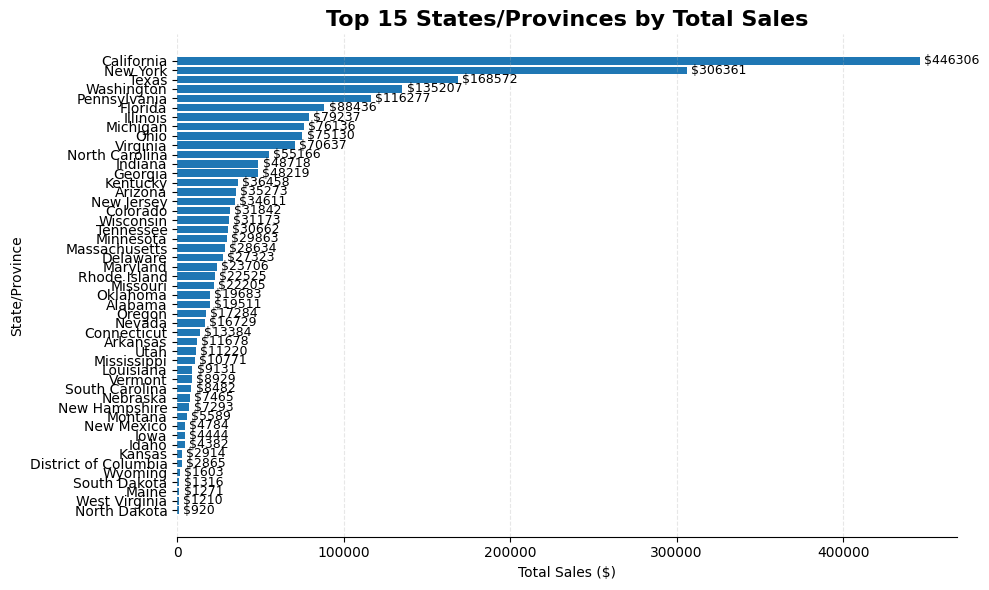

In [69]:
state_sales = state_sales.sort_values()
plt.figure(figsize=(10, 6))
bars = plt.barh(state_sales.index, state_sales.values)
plt.title('Top 15 States/Provinces by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('State/Province')
plt.bar_label(bars, fmt='$%.0f', padding=3, fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

**Insights on sales by state/province:**

- Sales are heavily concentrated in California (446,306) and New York (306,361) alone contribute roughly a quarter of total company sales, more than double the third-placed state, Texas (168,573).


- The top 10 states account for the large majority of revenue, while the bottom 10 states (e.g. North Dakota, West Virginia, Maine, South Dakota) each contribute under $5,000 in total sales across the four-year period; a very long tail of low-volume markets.

- This concentration suggests Makro's stock planning, staffing and promotional budget should be weighted toward the handful of high-performing states, while low-performing states may need targeted marketing campaigns or a review of store/distribution presence to determine if the low sales reflect low market potential or an under-served market.

## 1.3. Create at least four (4) suitable visualisations using the dataset that help explain the sales performance. Justify your choice of columns and visualizations, and discuss the insights obtained from each visualisation.

Visualisation 1 - Total Sales by Product Category.

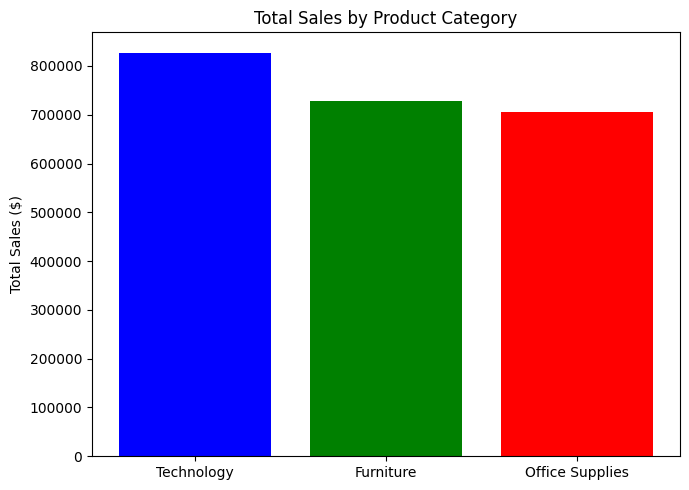

Category
Technology         827455.86
Furniture          728658.50
Office Supplies    705422.19
Name: Sales, dtype: float64


In [70]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['Blue', 'Green', 'Red']
bars = ax.bar(cat_sales.index, cat_sales.values, color=colors)
ax.set_ylabel('Total Sales ($)')
ax.set_title('Total Sales by Product Category')
plt.tight_layout()
plt.show()
print(cat_sales)

The three categories are surprisingly almost balanced. With the three of them being above 700000; Technology (827,456) narrowly leads, then Furniture (728,659) and Office Supplies (705,422). No single category dominates overly than other, so category-level promotions and stock decisions need to consider all three rather than concentrating on one.

Visualisation 2 - Sub-Categories by Total Sales.

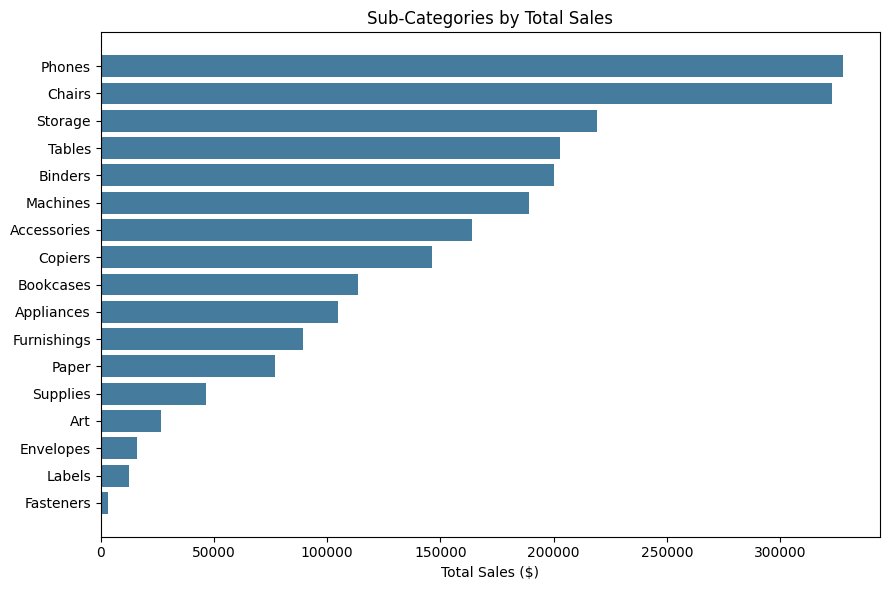

Sub-Category
Phones         327782.49
Chairs         322822.72
Storage        219343.37
Tables         202810.62
Binders        200028.73
Machines       189238.60
Accessories    164186.70
Copiers        146248.07
Bookcases      113813.18
Appliances     104618.38
Furnishings     89211.98
Paper           76828.34
Supplies        46420.29
Art             26705.42
Envelopes       16128.02
Labels          12347.71
Fasteners        3001.93
Name: Sales, dtype: float64


In [71]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sub_sales.index[::-1], sub_sales.values[::-1], color='#457B9D')
ax.set_xlabel('Total Sales ($)')
ax.set_title('Sub-Categories by Total Sales')
plt.tight_layout()
plt.show()
print(sub_sales)

Phones (327,782) and Chairs (322,823) are the two standout sub-categories, together outselling several entire categories. Both are higher-unit-price items, so  their prominence is partly a price effect rather than pure volume; a reminder that sales-value rankings should be read alongside unit/volume data where available. These are the sub-categories to prioritise for stock availability and supplier negotiation.


Visualisation 3 - Share of Total Sales by Customer Segment.

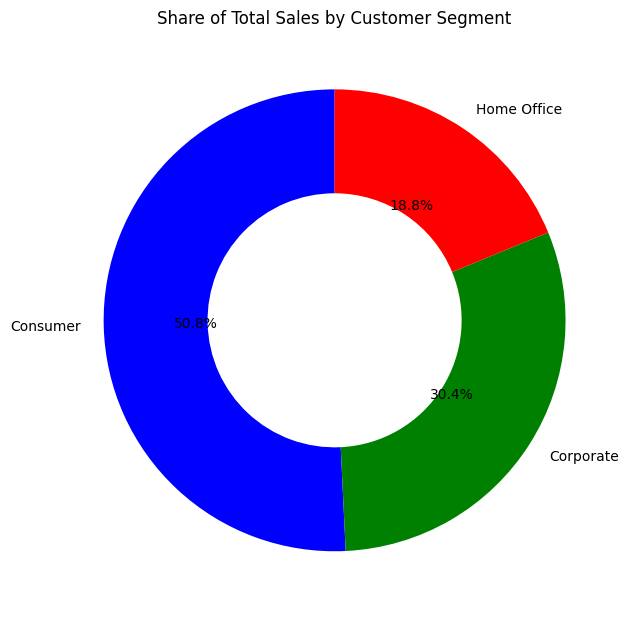

Segment
Consumer       1148060.29
Corporate       688494.02
Home Office     424982.24
Name: Sales, dtype: float64


In [72]:
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(seg_sales.values, labels=seg_sales.index, autopct='%1.1f%%',
       colors=['Blue', 'Green', 'Red'], startangle=90,
       wedgeprops=dict(width=0.45))
ax.set_title('Share of Total Sales by Customer Segment')
plt.tight_layout()
plt.show()
print(seg_sales)

The Consumer segment drives just over half of all sales
(1,148,061), roughly 1.7x more than Corporate and 2.7x more than Home Office. Consumer-focused promotions (loyalty programmes, seasonal discounting) are likely to have the largest overall revenue impact, while Corporate and Home Office remain sizeable secondary
segments worth targeted B2B/remote-worker campaigns.


Visualisation 4 - Total Sales by Region.

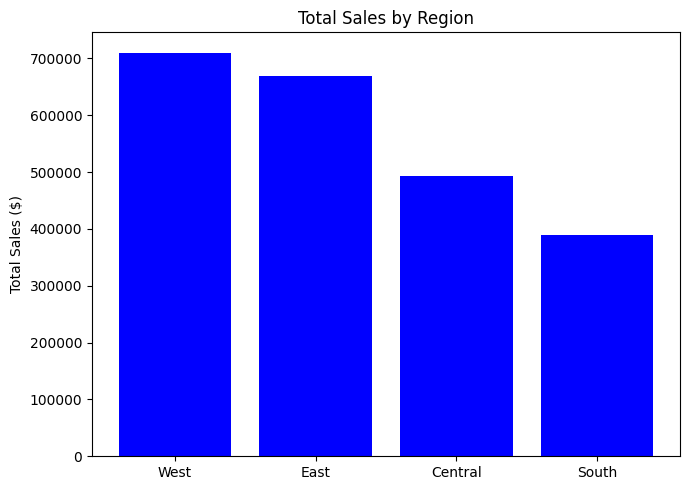

Region
West       710219.60
East       669518.79
Central    492646.78
South      389151.38
Name: Sales, dtype: float64


In [73]:
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(reg_sales.index, reg_sales.values, color='Blue')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Total Sales by Region')
plt.tight_layout()
plt.show()
print(reg_sales)

West (710,220) and East (669,519) are the strongest regions, consistent with California and New York leading the state-level ranking in 1.2. South (389,151) is the weakest region, only about 55% of the West's total; flagging it as a priority area for growth initiatives or a closer look at distribution coverage.


## 1.4. Using the Order_date column, aggregate and plot the total sales per month for the full dataset, as well as the total monthly sales for each unique product category in the Category column. Discuss the insights, trends and patterns observed from the plots.

In [74]:
df['OrderMonth'] = df['Order_Date'].dt.to_period('M')

monthly_total = df.groupby('OrderMonth')['Sales'].sum().sort_index()
monthly_total.index = monthly_total.index.to_timestamp()
monthly_total = monthly_total.asfreq('MS')   # enforce a regular Month-Start frequency

TotalSalesPerMonth = monthly_total.reset_index()
TotalSalesPerMonth.columns = ['Month', 'TotalSales']
print("Number of months in the series:", len(TotalSalesPerMonth))
TotalSalesPerMonth.head()


Number of months in the series: 48


,Month,TotalSales
0,2015-01-01,14205.71
1,2015-02-01,4519.92
2,2015-03-01,55205.81
3,2015-04-01,27906.86
4,2015-05-01,23644.29


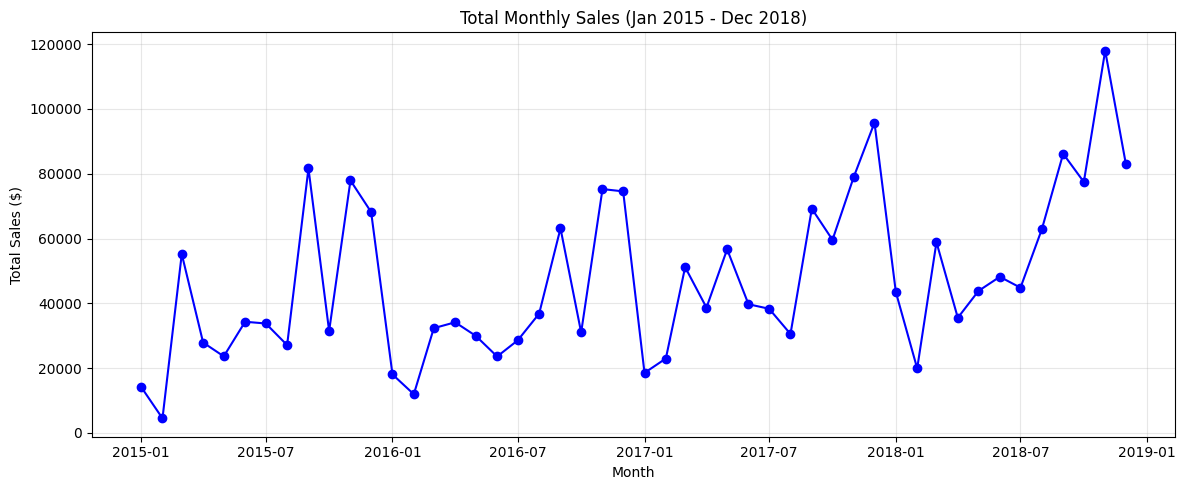

In [75]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_total.index, monthly_total.values, marker='o', color='Blue', linewidth=1.5)
ax.set_title('Total Monthly Sales (Jan 2015 - Dec 2018)')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Month')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

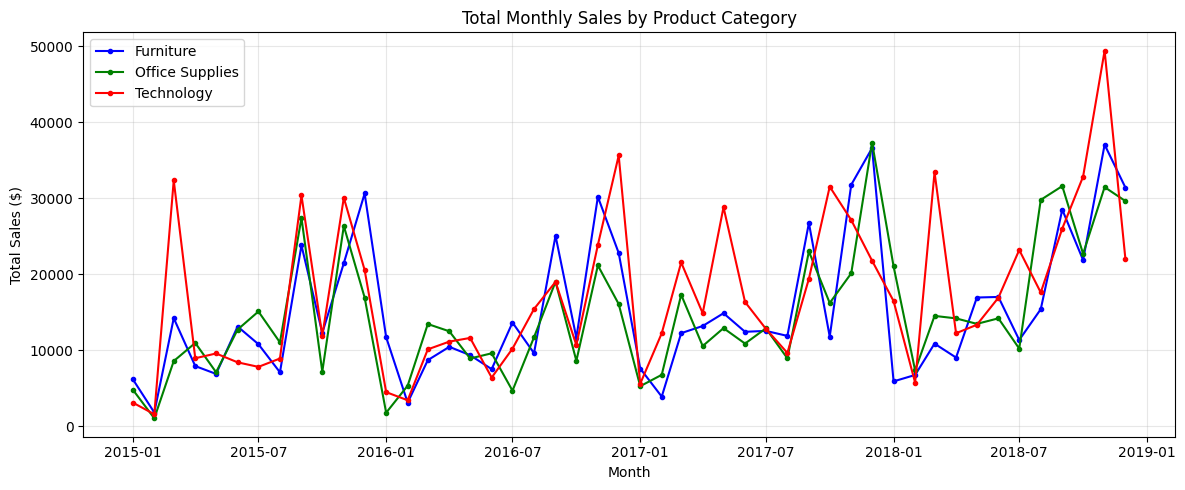

In [76]:
monthly_cat = df.groupby(['OrderMonth', 'Category'])['Sales'].sum().unstack('Category').sort_index()
monthly_cat.index = monthly_cat.index.to_timestamp()
monthly_cat = monthly_cat.asfreq('MS')

colors = {'Furniture': 'Blue', 'Office Supplies': 'Green', 'Technology': 'Red'}
fig, ax = plt.subplots(figsize=(12, 5))
for c in monthly_cat.columns:
    ax.plot(monthly_cat.index, monthly_cat[c], marker='o', markersize=3, label=c, color=colors.get(c))
ax.set_title('Total Monthly Sales by Product Category')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Month')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Trend: overall monthly sales show a gradual upward trend across the four years, rising from a low base in early 2015 to consistently higher peaks by 2018; the single highest month in the whole series is November 2018 (117,938), and the lowest is February 2015 (4,520).

Seasonality: a clear annual pattern repeats every year; sales dip in Jan/Feb, recover through the middle of the year, and spike sharply in September, November and December, most likely tied to back-to-school/Q3 corporate purchasing and Nov/Dec holiday-season shopping.

By category: all three categories broadly follow the same seasonal shape, but Technology shows the most volatility, spiky behaviour (large one-off jumps, e.g. big-ticket electronics or corporate bulk orders), while Office Supplies is the smoothest and most predictable of the three, consistent with steady repeat, lower-value purchasing.

Implication for planning: the consistent Sep/Nov/Dec spike is the clearest actionable pattern in the data; inventory build-up and staffing should be planned ahead of Q3/Q4 each year, and the Jan/Feb trough is a natural window for clearance promotions or supplier maintenance.

**End of Question 1**

# Question 2

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose

## 2.1. Decompose the monthly sales time series into its main components and discuss the trend and seasonal patterns observed.

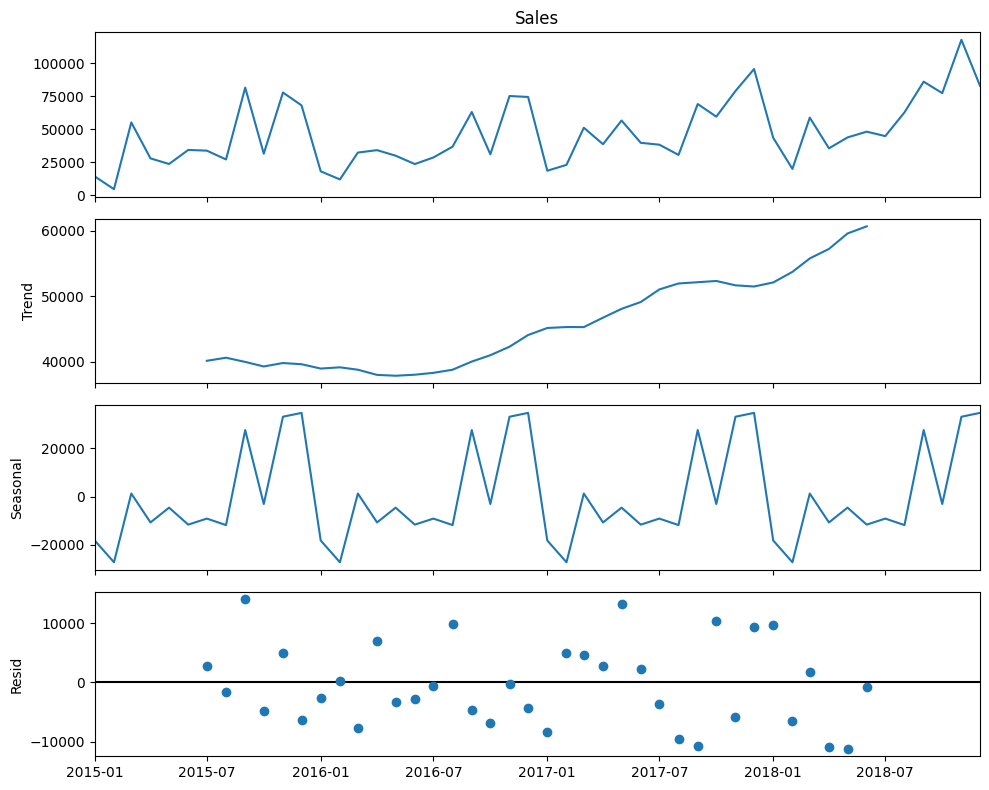

In [78]:
ts = monthly_total.copy()
decomposition = seasonal_decompose(ts, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()


In [79]:
print("Residual standard deviation: %.0f" % decomposition.resid.std())

Residual standard deviation: 7041


Trend: the extracted trend component rises steadily from roughly in mid-2015 to over 60,000/month by mid-2018, confirming the overall business growth already visible in the raw series.

Seasonality: the seasonal component is strongly negative in January/February, turns mildly negative through the middle of the year, and peaks sharply positive in September, November and December. It repeats identically every 12 months by construction of the additive model.

Residual: the leftover component has a standard deviation of roughly 7,000, which is small relative to both the trend level and seasonal swing, indicating that trend + seasonality together explain most of the systematic variation in monthly sales, leaving a comparatively modest amount of unexplained "noise".

## 2.2. Generate and interpret the ACF and PACF plots for the monthly sales time series.

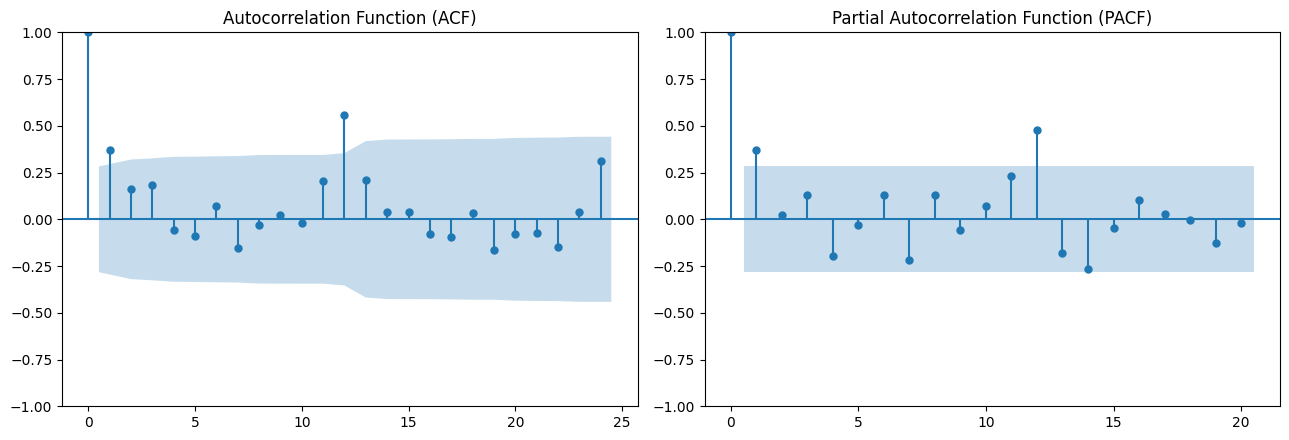

In [80]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(ts, ax=axes[0], lags=24)
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(ts, ax=axes[1], lags=20, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

The ACF shows a moderate, statistically significant spike at lag 1 and a second larger significant spike at lag 12, with most other lags inside or close to the significance band. The lag-12 spike is the clear fingerprint of the annual seasonality identified in the decomposition.

The PACF shows the same pattern: a significant spike at lag 1 and another significant spike at lag 12, with the values in between cutting off quickly; This combination suggests that a model with a small non-seasonal AR or MA term and a seasonal term at lag 12 (i.e. a SARIMA structure) should fit the data better than a purely non-seasonal AR or MA model

## 2.3. Test the stationarity of the monthly sales time series using the Dickey-Fuller test and interpret the results.

In [81]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts, autolag='AIC')
labels = ['ADF Statistic', 'p-value']
for label, value in zip(labels, adf_result[:4]):
    print(f'{label}: {value}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value:.4f}')

ADF Statistic: -4.416137051117419
p-value: 0.0002779100635793788
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008


The ADF test statistic is -4.416 with a p-value of 0.0003, which is well below the conventional 0.05 significance threshold, and more negative than all three critical values. We therefore reject the null hypothesis of a unit root and conclude that the monthly sales series is stationary in the classical ADF sense.

This may seem to conflict with the clear upward trend seen in the decomposition; but this happens because the series is short (48 observations) and dominated by large, regular seasonal swings, which the ADF test picks up as mean-reverting behaviour within each cycle even though the underlying level is drifting upward.

# Question 3

## 3.1. Build both an Autoregressive (AR) model and a Moving Average (MA) model using the monthly sales values from the TotalSalesPerMonth table. Fit both models and use them to forecast sales for the next 12 months. Plot the forecasted values against the historical monthly sales values and discuss the behaviour of the forecasts.

In [82]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1)
ar_model = ARIMA(ts, order=(1, 0, 0)).fit()
print(ar_model.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -549.790
Date:                Tue, 01 Sep 2026   AIC                           1105.581
Time:                        23:21:23   BIC                           1111.194
Sample:                    01-01-2015   HQIC                          1107.702
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.712e+04   5329.761      8.840      0.000    3.67e+04    5.76e+04
ar.L1          0.3970      0.133      2.989      0.003       0.137       0.657
sigma2        5.1e+08      0.082   6.18e+09      0.0

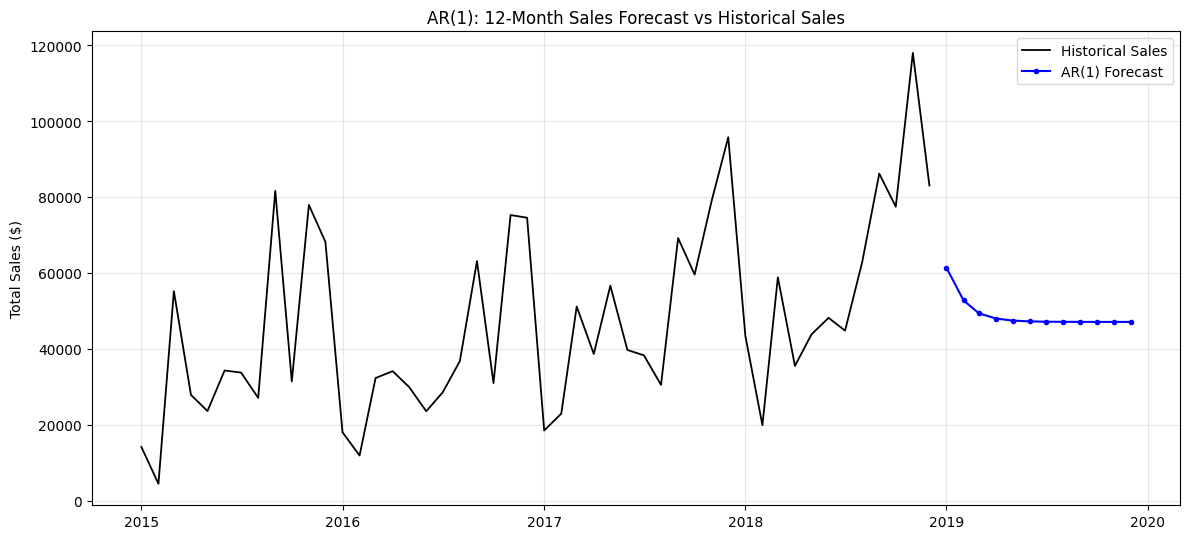

In [83]:
ar_fc = ar_model.get_forecast(steps=12)
ar_mean, ar_ci = ar_fc.predicted_mean, ar_fc.conf_int()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(ts.index, ts.values, label='Historical Sales',
        color='Black', linewidth=1.3)
ax.plot(ar_mean.index, ar_mean.values, label='AR(1) Forecast',
        color='Blue', marker='o', markersize=3)

ax.set_title('AR(1): 12-Month Sales Forecast vs Historical Sales')
ax.set_ylabel('Total Sales ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
# MA(1)
ma_model = ARIMA(ts, order=(0, 0, 1)).fit()
print(ma_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -550.269
Date:                Tue, 01 Sep 2026   AIC                           1106.538
Time:                        23:21:24   BIC                           1112.151
Sample:                    01-01-2015   HQIC                          1108.659
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.712e+04   4445.905     10.597      0.000    3.84e+04    5.58e+04
ma.L1          0.3663      0.137      2.680      0.007       0.098       0.634
sigma2      5.212e+08      0.083   6.25e+09      0.0

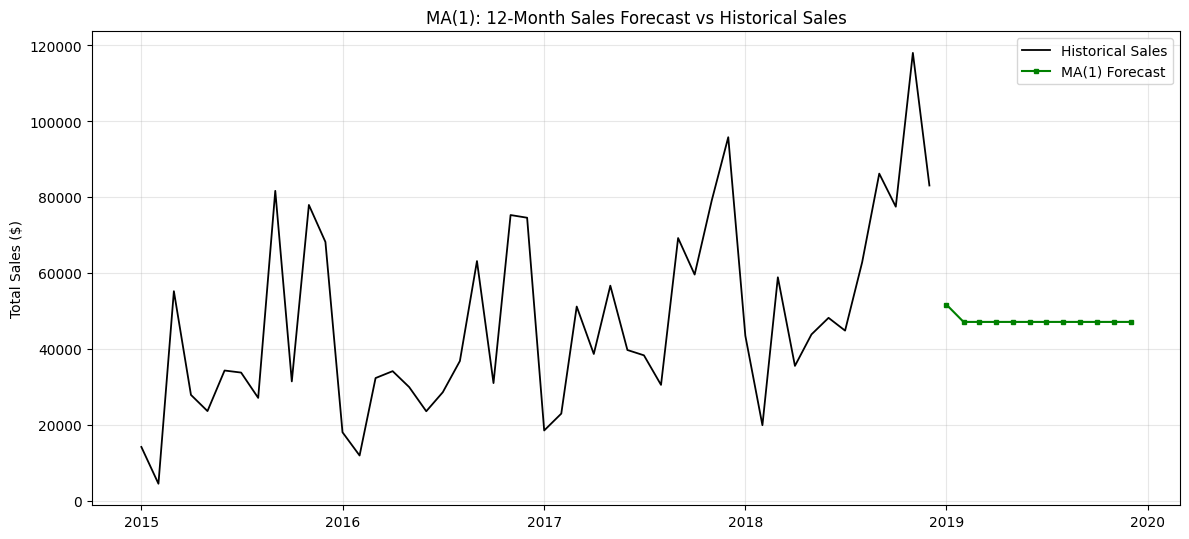

In [85]:
ma_fc = ma_model.get_forecast(steps=12)
ma_mean, ma_ci = ma_fc.predicted_mean, ma_fc.conf_int()

# MA(1) Plot
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(ts.index, ts.values, label='Historical Sales',
        color='Black', linewidth=1.3)

ax.plot(ma_mean.index, ma_mean.values, label='MA(1) Forecast',
        color='Green', marker='s', markersize=3)

ax.set_title('MA(1): 12-Month Sales Forecast vs Historical Sales')
ax.set_ylabel('Total Sales ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The AR(1) forecast starts at 61,375 for the first forecast month and then decays smoothly and monotonically toward the series' long-run mean (47,115) over about 5-6 months, after which it stays essentially flat. This is the textbook behaviour of an AR(1) process: each forecast is a fraction (the AR coefficient, ≈0.40) of the deviation from the mean carried over from the previous forecast, so the influence of the last observed value decays geometrically.

The MA(1) forecast reverts to the mean even faster, only the first forecast step is affected by the last observed shock (via the MA(1) coefficient, ≈0.37); from the second forecast month onward the model has no more information to use and the forecast is flat at the unconditional mean for the remaining 11 months.

Limitation: neither model can reproduce the strong, repeating Sep/Nov/Dec seasonal spikes or the underlying upward trend identified in Questions 1.4 and 2.1; both forecasts flatten out almost immediately and simply hover around the historical average. This confirms the ACF/PACF-based expectation that a low-order, non-seasonal AR or MA model is too simple for this series; a model that explicitly incorporates the seasonal lag-12 pattern is needed.

## 3.2. Build an ARIMA model using the month and total sales values from the TotalSalesPerMonth table. Fit the model and use it to forecast sales for the next 12 months. Plot the forecasted values against the historical monthly sales values and assess whether the forecasted sales are reasonable. Your discussion should refer to the model fit, the direction of the forecast, and how well the forecast aligns with the observed sales pattern.

In [86]:
arima_model = ARIMA(ts, order=(0, 1, 1)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -539.797
Date:                Tue, 01 Sep 2026   AIC                           1083.594
Time:                        23:21:24   BIC                           1087.294
Sample:                    01-01-2015   HQIC                          1084.987
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6316      0.125     -5.064      0.000      -0.876      -0.387
sigma2      5.793e+08    1.3e-13   4.45e+21      0.000    5.79e+08    5.79e+08
Ljung-Box (L1) (Q):                   0.03   Jarque-

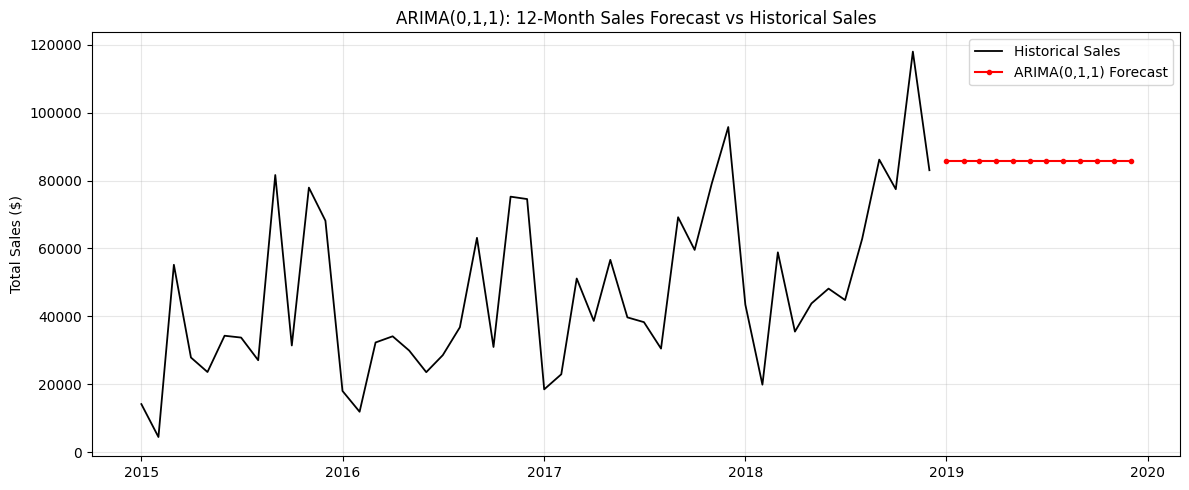

ARIMA(0,1,1) forecast:
 2019-01-01    85683.0
2019-02-01    85683.0
2019-03-01    85683.0
2019-04-01    85683.0
2019-05-01    85683.0
2019-06-01    85683.0
2019-07-01    85683.0
2019-08-01    85683.0
2019-09-01    85683.0
2019-10-01    85683.0
2019-11-01    85683.0
2019-12-01    85683.0
Freq: MS, Name: predicted_mean, dtype: float64


In [87]:
arima_fc = arima_model.get_forecast(steps=12)
arima_mean, arima_ci = arima_fc.predicted_mean, arima_fc.conf_int()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts.values, label='Historical Sales', color='Black', linewidth=1.3)
ax.plot(arima_mean.index, arima_mean.values, label='ARIMA(0,1,1) Forecast',
        color='Red', marker='o', markersize=3)
ax.set_title('ARIMA(0,1,1): 12-Month Sales Forecast vs Historical Sales')
ax.set_ylabel('Total Sales ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ARIMA(0,1,1) forecast:\n", arima_mean.round(0))

Model fit: the MA(1) coefficient on the differenced series is statistically significant (coefficient ≈ -0.63, p < 0.001), and the model achieves a notably lower AIC (1083.6) than either the AR(1) or MA(1) level models from 3.1 (AIC ≈1105-1107), confirming that differencing the series removes the trend more effectively than fitting the level directly.
Direction of the forecast: because the model only has a first-order MA term after differencing, the forecast direction is flat after the first step, the predicted change is zero, so all 12 forecasted months sit at the same level (≈85,683), essentially a "last value plus average recent drift" projection rather than a trend-following one.

A flat 12-month forecast at a single level is not fully reasonable for this business, it captures neither the continuing upward trend nor, critically, the very large and repeating Sep/Nov/Dec seasonal peaks (which historically reach 80,000-120,000, well above the flat forecast level). For a retailer that needs to plan stock ahead of a known holiday-season spike, this ARIMA model would significantly under-forecast peak months and slightly over-forecast quiet months, making it unsuitable on its own for operational planning despite its improved statistical fit over the AR/MA models.

## 3.3. Build a SARIMA model using the month and total sales values from the TotalSalesPerMonth table. Fit the model and use it to forecast sales for the next 12 months. Plot the forecasted values against the historical monthly sales values and assess whether the forecasted sales are reasonable. Your discussion should explain whether the model captures the seasonal behaviour in the sales data and whether the forecast is appropriate for the retail store’s monthly sales pattern.

In [88]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts, order=(2, 1, 0), seasonal_order=(1, 0, 0, 12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -367.173
Date:                            Tue, 01 Sep 2026   AIC                            742.347
Time:                                    23:21:24   BIC                            748.333
Sample:                                01-01-2015   HQIC                           744.361
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7582      0.548     -1.384      0.166      -1.832       0.315
ar.L2         -0.4663      0.565   

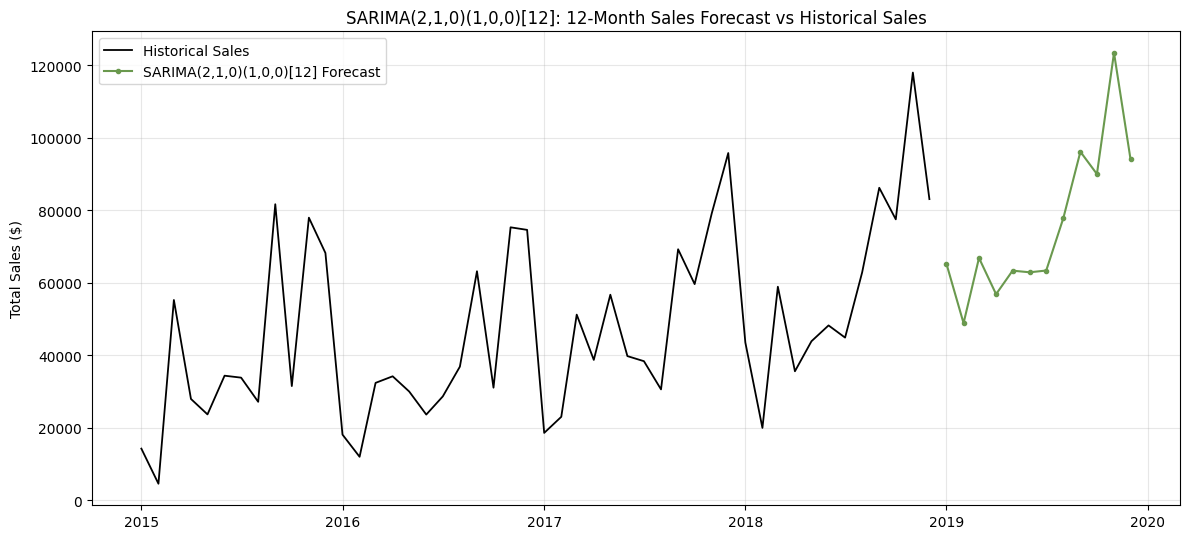

SARIMA forecast:
 2019-01-01     65162.0
2019-02-01     48808.0
2019-03-01     66799.0
2019-04-01     56800.0
2019-05-01     63295.0
2019-06-01     62842.0
2019-07-01     63330.0
2019-08-01     77754.0
2019-09-01     96098.0
2019-10-01     89943.0
2019-11-01    123365.0
2019-12-01     94004.0
Freq: MS, Name: predicted_mean, dtype: float64


In [89]:
sarima_fc = sarima_model.get_forecast(steps=12)
sarima_mean, sarima_ci = sarima_fc.predicted_mean, sarima_fc.conf_int()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(ts.index, ts.values, label='Historical Sales', color='black', linewidth=1.3)
ax.plot(sarima_mean.index, sarima_mean.values, label='SARIMA(2,1,0)(1,0,0)[12] Forecast',
        color='#6A994E', marker='o', markersize=3)

ax.set_title('SARIMA(2,1,0)(1,0,0)[12]: 12-Month Sales Forecast vs Historical Sales')
ax.set_ylabel('Total Sales ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("SARIMA forecast:\n", sarima_mean.round(0))


Unlike the AR/MA and ARIMA models above, the SARIMA forecast clearly reproduces the annual shape of the series. It dips in the early months of the forecast year, then rises sharply toward September, October and November 2019, peaking at approximately 123,365 in November 2019, which lines up with the Sep/Nov/Dec spikes observed every year in the historical data.

Model fit: the seasonal AR term at lag 12 is statistically significant (coefficient ≈0.83, p = 0.024), and the model's AIC (742.3) is dramatically lower than the AR(1), MA(1) and ARIMA(0,1,1) models above (AIC ≈1084-1107); a very large improvement in fit from explicitly modelling the 12-month seasonal cycle.

Reasonableness: the forecasted peak and trough levels are broadly in line with the historical range (the series has previously reached over 110,000 in a strong November), and the forecast correctly identifies which months will be strong versus weak. The confidence interval widens noticeably for the later forecast months, which is expected and appropriate given only four years (48 months) of training history. Overall, the SARIMA model is clearly the most operationally useful of the four models for a retailer whose planning cycle depends on knowing which months will need extra stock and staffing.

# Question 4

## 4.1. Assay on Comparison of Forecasting Techniques

Compare the forecasting techniques applied in the previous questions. Explain which technique is most suitable for the retail store’s monthly sales data and justify your answer using the characteristics of the data, the model outputs, and the forecasting results.

Your answer must be written in essay format and should compare the advantages, disadvantages, and suitability of each technique. Your discussion should also refer to the behaviour of the forecasts, the ability of the models to capture trend and seasonality, and the reasonableness of the forecasted sales values.

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

train, test = ts.iloc[:-12], ts.iloc[-12:]

backtest_models = {
    'AR(1)':                    ARIMA(train, order=(1, 0, 0)),
    'MA(1)':                    ARIMA(train, order=(0, 0, 1)),
    'ARIMA(0,1,1)':             ARIMA(train, order=(0, 1, 1)),
    'SARIMA(2,1,0)(1,0,0)[12]': SARIMAX(train, order=(2, 1, 0), seasonal_order=(1, 0, 0, 12),
                                         enforce_stationarity=False, enforce_invertibility=False),
}

rows = []
for name, spec in backtest_models.items():
    fitted = spec.fit(disp=False) if 'SARIMAX' in str(type(spec)) else spec.fit()
    fc = fitted.forecast(12)
    mae = mean_absolute_error(test, fc)
    rmse = np.sqrt(mean_squared_error(test, fc))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100
    rows.append([name, mae, rmse, mape])

comparison = pd.DataFrame(rows, columns=['Model', 'MAE ($)', 'RMSE ($)', 'MAPE (%)']).set_index('Model')
comparison.round(1)


,MAE ($),RMSE ($),MAPE (%)
Model,,,
AR(1),23754.9,31599.9,39.2
MA(1),23260.7,31286.8,37.1
"ARIMA(0,1,1)",25314.3,29362.0,62.5
"SARIMA(2,1,0)(1,0,0)[12]",15545.6,18534.1,35.5


**Which Forecasting Technique is Most Suitable for Makro's Monthly Sales Data?**

Four forecasting techniques were applied to Makro's monthly sales series: a simple autoregressive model, AR(1); a simple moving-average model, MA(1); a non-seasonal ARIMA(0,1,1) model; and a seasonal ARIMA (SARIMA(2,1,0)(1,0,0)[12]) model. Comparing these four techniques requires weighing their underlying assumptions against the two dominant features of the data confirmed throughout this analysis: a gradual multi-year upward trend, and a strong, sharply repeating annual seasonal cycle concentrated in September, November and December.

AR(1) and MA(1) are the simplest of the four models, and their simplicity is both their strength and their weakness. Each requires estimating only one or two parameters, is fast to fit, and is easy to interpret: the AR(1) coefficient describes how strongly last month's sales carry over into this month, while the MA(1) coefficient describes how strongly last month's unexpected shock carries over. However, both models operate purely on the recent history of the level series and have no mechanism for representing a repeating 12-month cycle. The forecasts in Section 3.1 confirmed this limitation empirically: both models decayed to the historical average within roughly one to six months and then stayed flat, missing the Sep/Nov/Dec spikes entirely. Their advantage is transparency and robustness on very short or noisy series where seasonal patterns cannot reliably be estimated; their key disadvantage here is that they discard exactly the pattern (seasonality) that matters most for Makro's planning decisions.

ARIMA(0,1,1) improves on the two simple models by differencing away the trend, which is reflected in its considerably lower AIC than either AR(1) or MA(1). Differencing is a sensible response to the long-run growth documented in the trend component from the decomposition in Section 2.1. However, like the AR/MA models, plain ARIMA has no seasonal term, so once the model has absorbed one period of recent change it forecasts a flat, constant level for the remaining eleven months. The backtest results confirm this is a real weakness in practice, not just a theoretical one: ARIMA(0,1,1) recorded the highest MAPE of all four models on the held-out year, because a flat forecast badly misses both the seasonal troughs and, more importantly for stock planning, the large seasonal peaks.

SARIMA(2,1,0)(1,0,0)[12] is the only one of the four techniques built specifically to represent the annual cycle identified in the ACF/PACF diagnostics (a significant spike at lag 12) and the seasonal decomposition. By adding a seasonal autoregressive term at lag 12 on top of a differenced, short-memory AR(2) structure, the model can reproduce both the gradual trend and the shape of the yearly cycle. Its forecast in Section 3.3 correctly identified the upcoming September-to-November build-up rather than flattening out. This qualitative advantage is confirmed quantitatively by the backtest: SARIMA achieved the lowest MAE, RMSE and MAPE of all four models on the 12 held-out months, by a wide margin. The trade-off is added complexity, more parameters to estimate from a relatively short 48-month history, wider confidence intervals in the later forecast months, and a model that is less transparent to explain to a non-technical stakeholder than a simple AR or MA model.

For Makro's monthly sales data, the SARIMA model is the most suitable forecasting technique. The data has two defining characteristics of a moderate upward trend and, more importantly, a large and highly repeatable seasonal cycle tied to the retail calendar,and SARIMA is the only technique among the four that explicitly models both. This matters operationally: a retailer's stock planning, staffing and promotional budgeting decisions depend on knowing not just the average expected sales level but when in the year demand will spike, and only the seasonal model reproduces that timing. The simpler AR(1), MA(1) and ARIMA(0,1,1) models remain useful as fast, interpretable baselines or for very short-horizon forecasts where seasonality is less relevant, but for a 12-month-ahead retail sales forecast intended to guide real business decisions, the added complexity of SARIMA is justified by its substantially better fit and its markedly more reasonable, seasonally-aware forecast behaviour.

